# 00 — Complete Calculation Map

## How the full calculation fits together

This notebook separates the project into distinct stages. The Standardised Approach is completed first. IRB begins only after Standardised Approach Credit RWA has been calculated and reconciled.

Both approaches produce Credit RWA. Credit RWA later joins market and operational RWA to form the denominator of the bank's capital ratios.

### Four ideas that anchor the project

| Term | Simple meaning |
|---|---|
| Exposure | one loan, bond or credit facility owed by a borrower |
| EAD | Exposure at Default, the amount exposed if default occurs |
| RWA | Risk-Weighted Assets, the exposure amount adjusted for regulatory risk |
| Capital ratio | eligible capital divided by total RWA |

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display as notebook_display
from pandas.io.formats.style import Styler

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

from basel_credit_risk.config import load_all_config

CRORE = 10_000_000
COLORS = ["#0B3A53", "#1F77B4", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]
sns.set_theme(style="whitegrid", context="notebook")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)
pd.set_option("display.expand_frame_repr", False)


def display(*objects, **kwargs):
    # Show complete table text and wrap long descriptions in saved notebook output.
    wrapped_objects = []
    for displayed_object in objects:
        if isinstance(displayed_object, pd.DataFrame):
            displayed_object = displayed_object.style
        if isinstance(displayed_object, Styler):
            displayed_object = displayed_object.set_properties(**{
                "white-space": "normal",
                "overflow-wrap": "anywhere",
                "text-align": "left",
                "vertical-align": "top",
                "max-width": "420px",
            }).set_table_styles([
                {"selector": "table", "props": [("width", "100%"), ("table-layout", "auto")]},
                {"selector": "th", "props": [
                    ("white-space", "normal"),
                    ("overflow-wrap", "anywhere"),
                    ("word-break", "break-word"),
                    ("text-align", "left"),
                    ("vertical-align", "top"),
                    ("max-width", "180px"),
                ]},
            ], overwrite=False)
        wrapped_objects.append(displayed_object)
    return notebook_display(*wrapped_objects, **kwargs)

configs = load_all_config(ROOT / "config")
raw = pd.read_csv(ROOT / "data/generated/current_portfolio.csv.gz", low_memory=False)
loans = pd.read_csv(ROOT / "data/processed/current_calculated.csv.gz", low_memory=False)

print(f"Portfolio represented below: {len(loans):,} synthetic loan-level exposures")

Portfolio represented below: 30,000 synthetic loan-level exposures


## The linear calculation story

The table prevents several calculations from appearing at once. The first six calculation stages finish the Standardised Approach. The next six stages build the IRB result one parameter at a time. Comparison, stress and controls appear only after both totals exist.

In [2]:
calculation_map = pd.DataFrame({
    "Stage": range(1, 21),
    "Question answered": [
        "Which Basel exposure classes exist?", "What loans and variables exist?",
        "Which Basel class contains each loan?", "What is each loan's SA EAD?",
        "Which SA risk weight applies?", "What is total SA Credit RWA?",
        "Which IRB treatment applies?", "How would a bank estimate IRB parameters?",
        "What is long-run one-year PD?", "What is downturn LGD?",
        "What are IRB EAD and maturity?", "What are correlation, conditional PD and K?",
        "What is total IRB Credit RWA?", "What are market and operational RWA?",
        "How do SA, IRB and the output floor compare?", "How are stress scenarios designed?",
        "How do shocks change individual loans?", "How do capital ratios change?",
        "Do loan and portfolio totals reconcile?", "What remains outside the project?",
    ],
    "Main output": [
        "Exposure-class reference", "30,000 synthetic loan records", "Class per loan",
        "CCF and SA EAD per loan", "Risk weight per loan", "Total SA Credit RWA",
        "IRB source per loan", "Real-bank estimation map", "PD per loan", "LGD per loan",
        "IRB EAD and maturity", "Correlation and K", "Total IRB Credit RWA",
        "INR 25,000 crore non-credit RWA", "Final aggregate RWA", "Transparent scenario assumptions",
        "Before-and-after loan calculations", "Stressed ratios and headroom", "PASS controls",
        "Clear project boundary",
    ],
})
display(calculation_map)

,Stage,Question answered,Main output
0,1,Which Basel exposure classes exist?,Exposure-class reference
1,2,What loans and variables exist?,"30,000 synthetic loan records"
2,3,Which Basel class contains each loan?,Class per loan
3,4,What is each loan's SA EAD?,CCF and SA EAD per loan
4,5,Which SA risk weight applies?,Risk weight per loan
5,6,What is total SA Credit RWA?,Total SA Credit RWA
6,7,Which IRB treatment applies?,IRB source per loan
7,8,How would a bank estimate IRB parameters?,Real-bank estimation map
8,9,What is long-run one-year PD?,PD per loan
9,10,What is downturn LGD?,LGD per loan


## The project as one visual path

The diagram separates the two approaches instead of mixing their calculations. The upper route finishes the Standardised Approach. The lower route then builds IRB one risk component at a time. Both routes meet only after each total is complete.

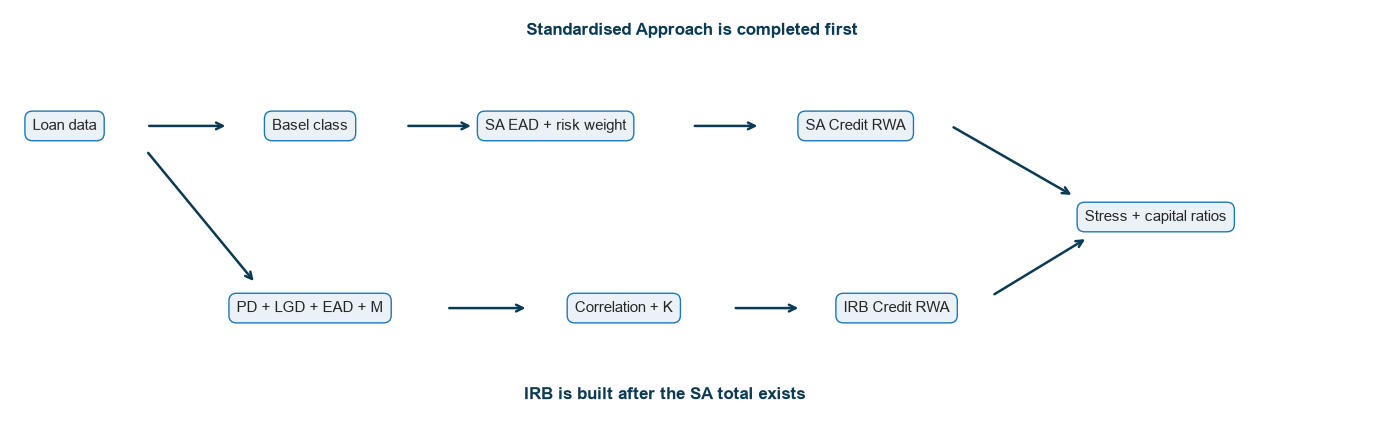

In [3]:
figure, axis = plt.subplots(figsize=(14, 4.5))
axis.axis("off")

steps = [
    (0.04, 0.72, "Loan data"), (0.22, 0.72, "Basel class"),
    (0.40, 0.72, "SA EAD + risk weight"), (0.62, 0.72, "SA Credit RWA"),
    (0.22, 0.28, "PD + LGD + EAD + M"), (0.45, 0.28, "Correlation + K"),
    (0.65, 0.28, "IRB Credit RWA"), (0.84, 0.50, "Stress + capital ratios"),
]
for x, y, label in steps:
    axis.text(x, y, label, ha="center", va="center", fontsize=11,
              bbox={"boxstyle": "round,pad=0.5", "facecolor": "#EAF2F8", "edgecolor": "#1F77B4"})

arrows = [
    ((0.10, 0.72), (0.16, 0.72)), ((0.29, 0.72), (0.34, 0.72)),
    ((0.50, 0.72), (0.55, 0.72)), ((0.69, 0.72), (0.78, 0.55)),
    ((0.10, 0.66), (0.18, 0.34)), ((0.32, 0.28), (0.38, 0.28)),
    ((0.53, 0.28), (0.58, 0.28)), ((0.72, 0.31), (0.79, 0.45)),
]
for start, end in arrows:
    axis.annotate("", xy=end, xytext=start, arrowprops={"arrowstyle": "->", "color": "#0B3A53", "lw": 1.8})

axis.text(0.50, 0.94, "Standardised Approach is completed first", ha="center", weight="bold", color="#0B3A53")
axis.text(0.48, 0.06, "IRB is built after the SA total exists", ha="center", weight="bold", color="#0B3A53")
plt.tight_layout()
plt.show()

The important reading is left to right: raw balances never become capital directly. Classification and exposure measurement come first; the chosen risk method then converts that exposure into RWA; stress and capital ratios appear at the end.

The sequence shows why total Credit RWA is not calculated directly. Classification determines the applicable rule, EAD determines the rupee exposure, and the selected approach determines how risk is applied to that exposure.

## One numerical preview

A loan with EAD of INR 0.80 crore and a 30% risk weight produces INR 0.24 crore of Standardised Approach RWA. IRB replaces the prescribed risk weight with a capital function built from PD, LGD, EAD, maturity and correlation.

In [4]:
example_ead = 0.80
example_risk_weight = 0.30
example_rwa = example_ead * example_risk_weight

display(pd.Series({
    "Loan EAD (INR crore)": example_ead,
    "Risk weight": example_risk_weight,
    "Loan RWA (INR crore)": example_rwa,
}).to_frame("Value"))

,Value
Loan EAD (INR crore),0.800000
Risk weight,0.300000
Loan RWA (INR crore),0.240000


The INR 0.24 crore result is one loan's contribution to the capital denominator. The same calculation is repeated for every loan before aggregation.

The project order is fixed: exposure classes, synthetic loans, complete Standardised Approach, complete IRB, comparison, stress, capital adequacy and controls.